In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy

from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.color import rgb2gray, rgb2hsv
from skimage.filters import threshold_otsu
#from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)

In [2]:
import napari
from napari.utils import nbscreenshot

In [3]:
from pyclesperanto_prototype import imshow
import pyclesperanto_prototype as cle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [4]:
cle.available_device_names()
# For 3D processing, powerful graphics
# processing units might be necessary
cle.select_device('TX')

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with TX in their name. Using Apple M1 Max instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


<Apple M1 Max on Platform: Apple (2 refs)>

In [5]:
#import czifile
from aicsimageio import AICSImage
from aicsimageio.writers import OmeTiffWriter

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.color import rgb2gray, rgb2hsv
from skimage.filters import threshold_otsu

In [10]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/processed/"
#fileName = '675995-LNP1-limb2.jpg'
fileName = '675982-LNP1-limb2.jpg'
#fileName = '675907-LNP4-limb1.jpg'
#fileName = "675911-LNP3-limb2.jpg"


path_results = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/' \
        + 'test' + '/'
outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/test/


In [11]:
#################################
## Test segment the color images
## original example from https://medium.com/@flippygarcia/color-image-segmentation-using-python-part-1-11319b4dccad
#################################

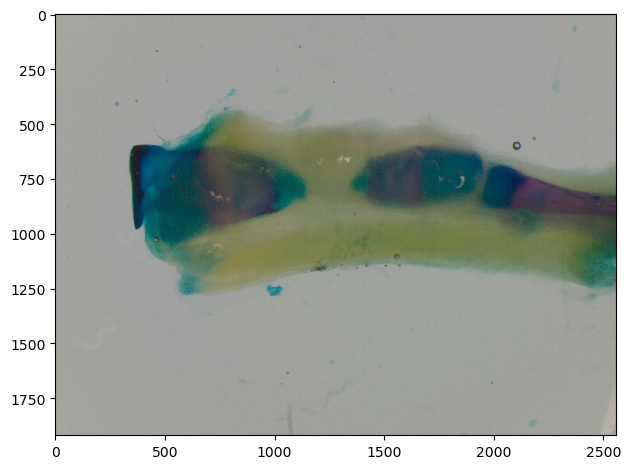

In [12]:
# Load Original Image
img_test1 = imread(os.path.join(inputDir, fileName))
img_test1_gs = rgb2gray(img_test1)
img_col = img_test1
img_hsv = rgb2hsv(img_test1)

imshow(img_test1)

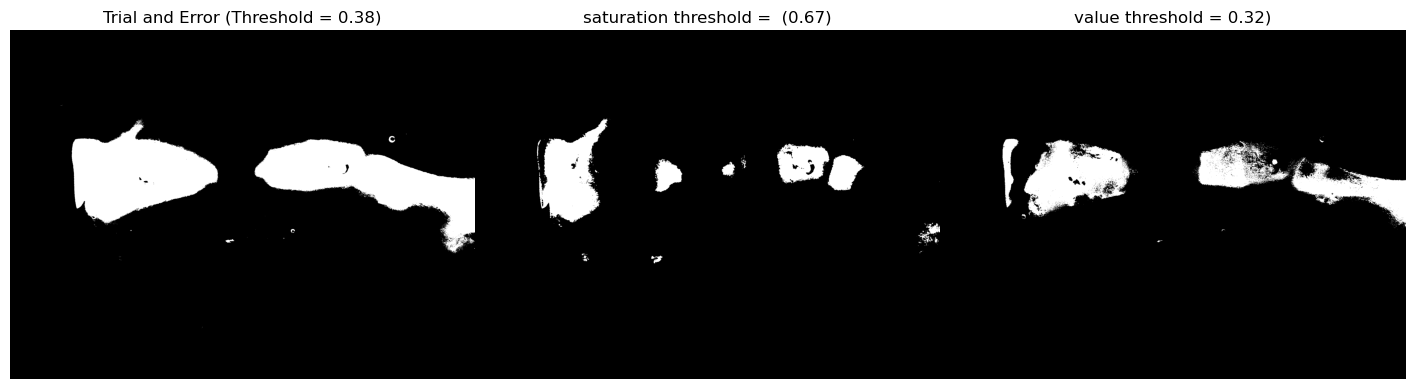

In [13]:
th_gray = 0.38

th_saturation = 0.67
th_value = 0.32

# Plot
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

fig.subplots_adjust(wspace=0)
ax[0].set_title(f"Trial and Error (Threshold = {th_gray:.2f})")
ax[0].imshow(img_test1_gs < th_gray, cmap='gray')
ax[0].set_axis_off()

ax[1].set_title(f"saturation threshold =  ({th_saturation:.2f})")
ax[1].imshow(img_hsv[:, :, 1] > th_saturation, cmap='gray')
ax[1].set_axis_off()
ax[2].set_title(f"value threshold = {th_value:.2f})")
ax[2].imshow(img_hsv[:, :, 2] < th_value, cmap='gray')
ax[2].set_axis_off()

In [14]:
img_test1.shape

(1920, 2560, 3)

In [15]:
np.max(img_test1_gs)

np.float64(0.7546749019607844)

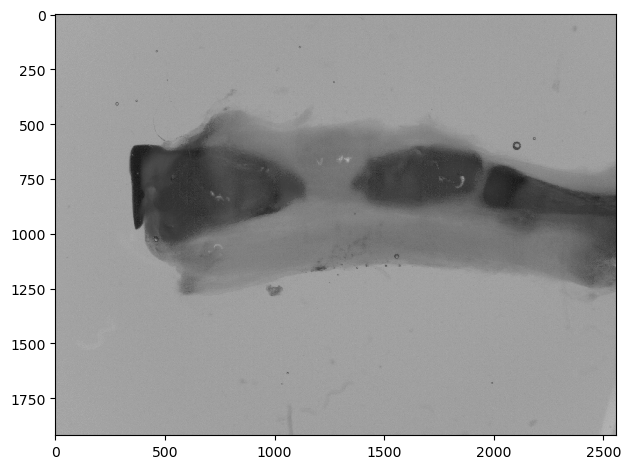

In [16]:
imshow(img_test1_gs)

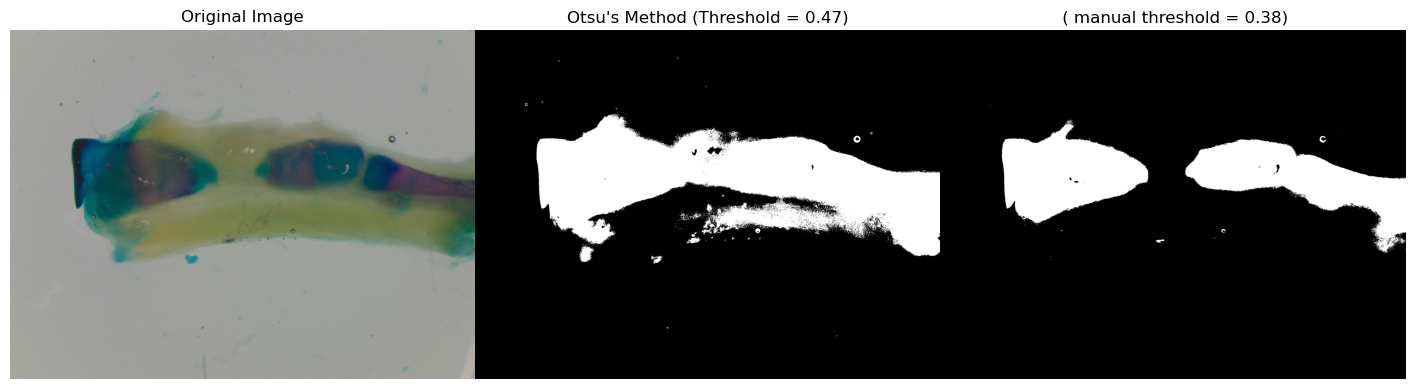

In [18]:
# Using Otsu's Method
th_otsu = threshold_otsu(img_test1_gs)

#th_otsu = 0.25
img_test1_otsu = img_test1_gs < th_otsu

# After several trial and error this is the best threshold
th = 0.38
img_test1_bn = img_test1_gs < th

# Plot
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
fig.subplots_adjust(wspace=0)
ax[0].set_title("Original Image")
ax[0].imshow(img_test1)
ax[0].set_axis_off()
ax[1].set_title(f"Otsu's Method (Threshold = {th_otsu:.2f})")
ax[1].imshow(img_test1_otsu, cmap='gray')
ax[1].set_axis_off()
ax[2].set_title(f" ( manual threshold = {th:.2f})")
ax[2].imshow(img_test1_bn, cmap='gray')
ax[2].set_axis_off()

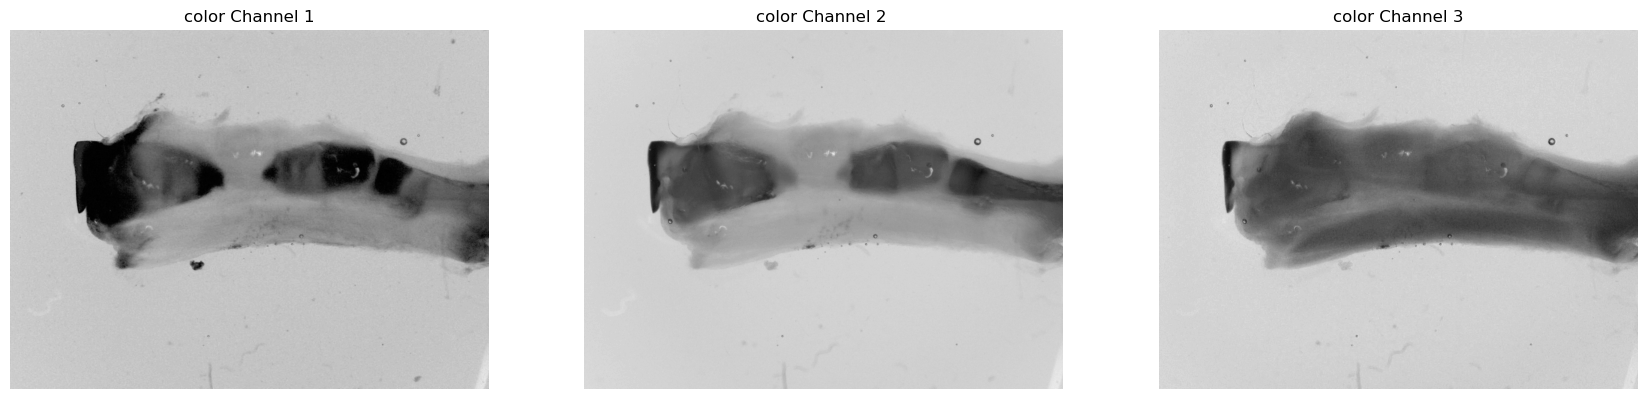

In [19]:
# check the different color channels
# Plot
fig, ax = plt.subplots(1, 3, figsize=(21, 7))
ax[0].set_title("color Channel 1")
ax[0].imshow(img_col[:, :, 0], cmap='gray')
ax[0].set_axis_off()
ax[1].set_title("color Channel 2 ")
ax[1].imshow(img_col[:, :, 1], cmap='gray')
ax[1].set_axis_off()
ax[2].set_title("color Channel 3")
ax[2].imshow(img_col[:, :, 2], cmap='gray')
ax[2].set_axis_off()
plt.show()

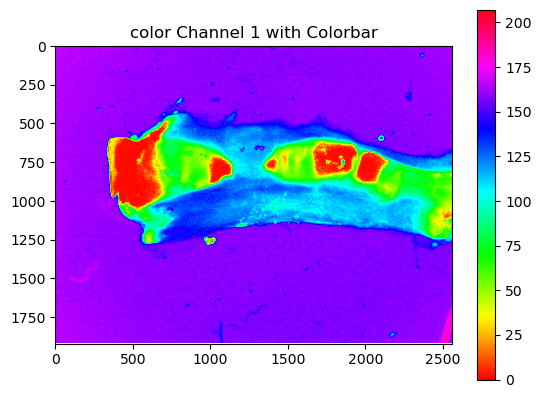

In [20]:
# Plot Hue Channel with Colorbar
plt.imshow(img_col[:, :, 0], cmap='hsv')
plt.title('color Channel 1 with Colorbar')
plt.colorbar()
plt.show()

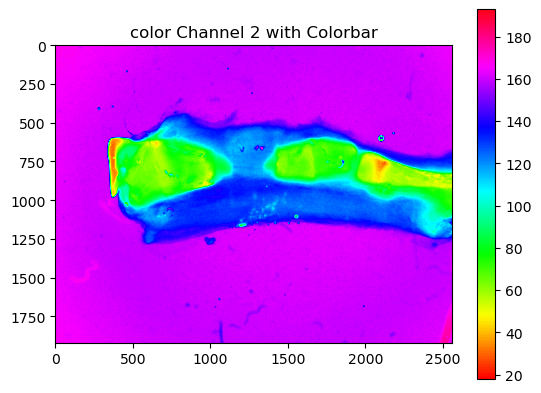

In [21]:
# Plot Hue Channel with Colorbar
plt.imshow(img_col[:, :, 1], cmap='hsv')
plt.title('color Channel 2 with Colorbar')
plt.colorbar()
plt.show()

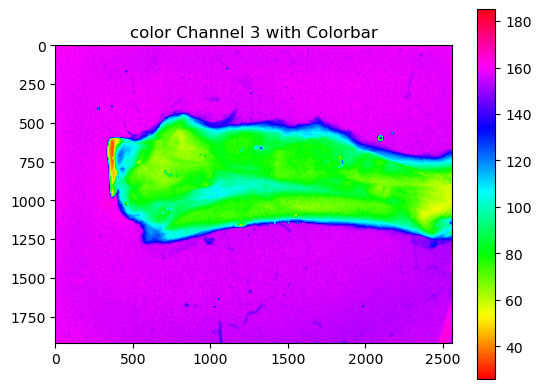

In [22]:
# Plot Hue Channel with Colorbar
plt.imshow(img_col[:, :, 2], cmap='hsv')
plt.title('color Channel 3 with Colorbar')
plt.colorbar()
plt.show()

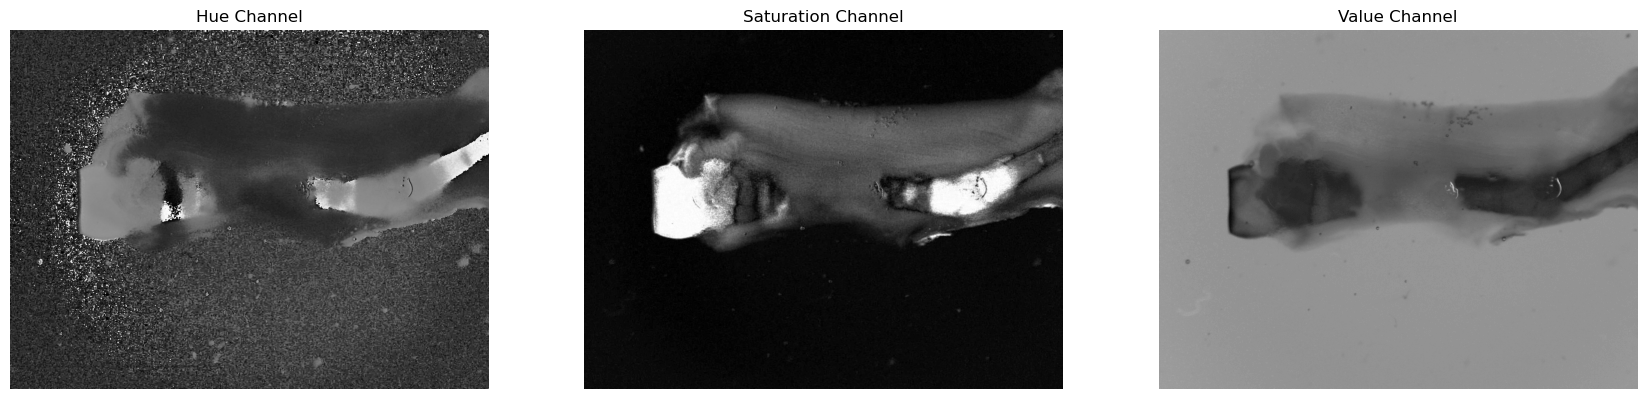

In [239]:
# Plot
fig, ax = plt.subplots(1, 3, figsize=(21, 7))
ax[0].set_title("Hue Channel")
ax[0].imshow(img_hsv[:, :, 0], cmap='gray')
ax[0].set_axis_off()
ax[1].set_title("Saturation Channel")
ax[1].imshow(img_hsv[:, :, 1], cmap='gray')
ax[1].set_axis_off()
ax[2].set_title("Value Channel")
ax[2].imshow(img_hsv[:, :, 2], cmap='gray')
ax[2].set_axis_off()
plt.show()

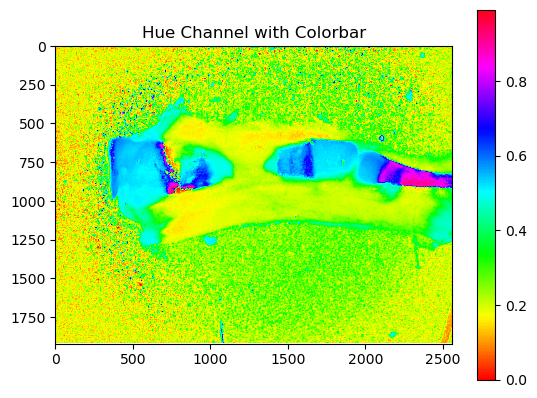

In [23]:
# Plot Hue Channel with Colorbar
plt.imshow(img_hsv[:, :, 0], cmap='hsv')
plt.title('Hue Channel with Colorbar')
plt.colorbar()
plt.show()

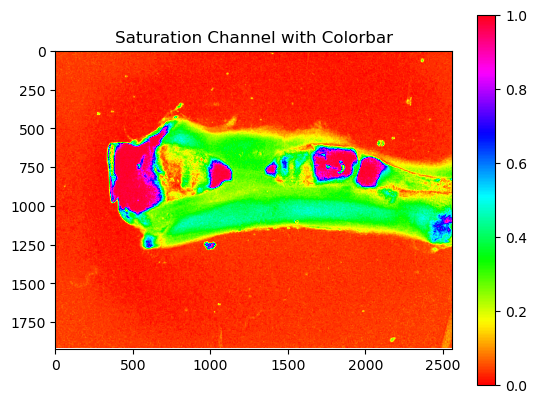

In [24]:
# Plot Hue Channel with Colorbar
plt.imshow(img_hsv[:, :, 1], cmap='hsv')
plt.title('Saturation Channel with Colorbar')
plt.colorbar()
plt.show()

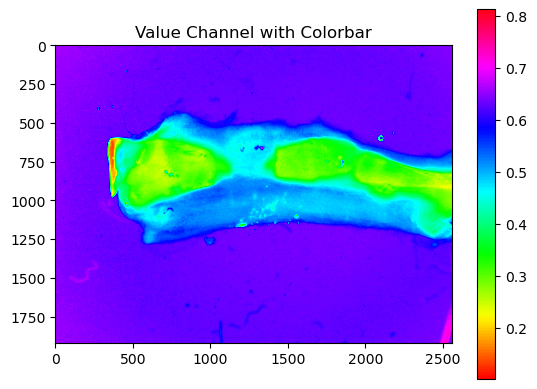

In [25]:
# Plot Hue Channel with Colorbar
plt.imshow(img_hsv[:, :, 2], cmap='hsv')
plt.title('Value Channel with Colorbar')
plt.colorbar()
plt.show()

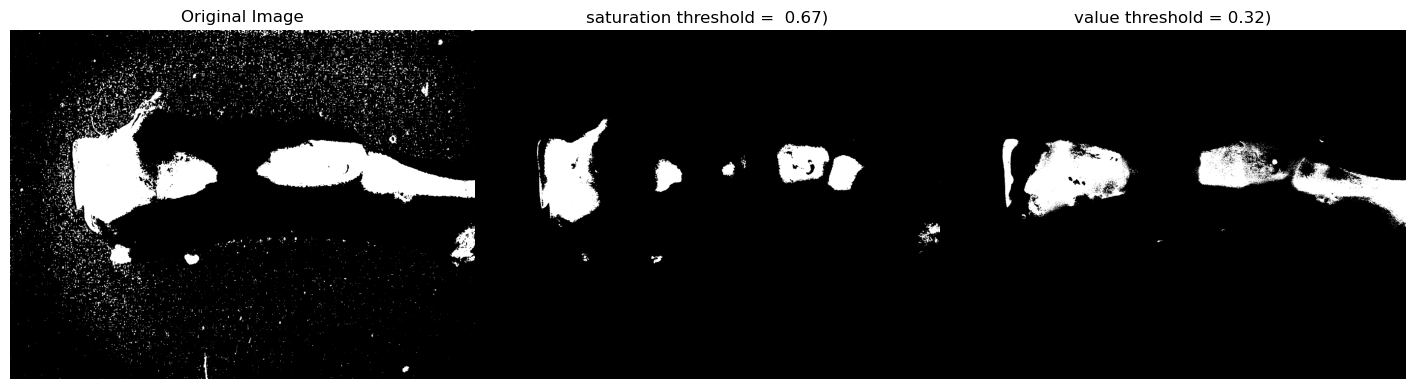

In [26]:
#th_otsu = 0.25
th_hue = 0.45
th_saturation = 0.67
th_value = 0.32

# Plot
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
fig.subplots_adjust(wspace=0)
ax[0].set_title("Original Image")
ax[0].imshow(img_hsv[:, :, 0] > th_hue, cmap='gray')
ax[0].set_axis_off()
ax[1].set_title(f"saturation threshold =  {th_saturation:.2f})")
ax[1].imshow(img_hsv[:, :, 1] > th_saturation, cmap='gray')
ax[1].set_axis_off()
ax[2].set_title(f"value threshold = {th_value:.2f})")
ax[2].imshow(img_hsv[:, :, 2] < th_value, cmap='gray')
ax[2].set_axis_off()

In [38]:
#######################################
## downstream of ilastik analysis
#######################################

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy

from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.color import rgb2gray, rgb2hsv
from skimage.filters import threshold_otsu
#from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)

In [46]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/processed/ilastik_batch"
#fileName = '675995-LNP1-limb2.jpg'
#fileName = '675982-LNP1-limb2_Probabilities.tif'
#fileName = '675953-LNP1-limb1_Probabilities.tif'
fileName = '675907-LNP4-limb1_Probabilities.tif'

path_results = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/' \
        + 'downstream_ilastik' + '/'
outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)
print(fileName)

/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/results/downstream_ilastik/
675907-LNP4-limb1_Probabilities.tif


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, measure, morphology, color
from skimage.draw import rectangle_perimeter

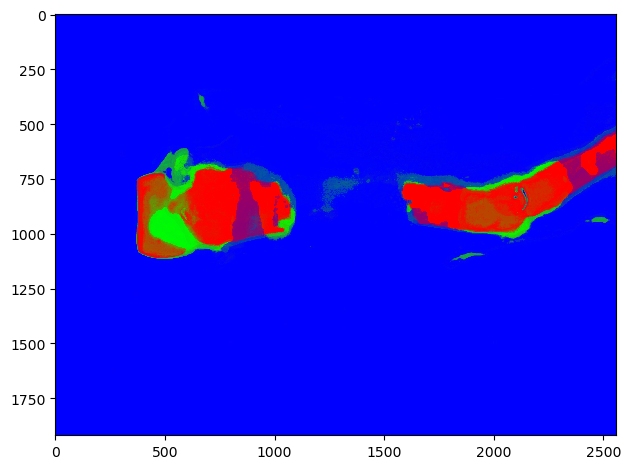

In [48]:
# Load Original Image
img_prob = imread(os.path.join(inputDir, fileName))
imshow(img_prob)

In [49]:
img_prob.shape

(1920, 2560, 3)

In [129]:
bone_mask = img_prob[:, :, 0] > 0.7;
cart_mask = img_prob[:, :, 1] > 0.8;

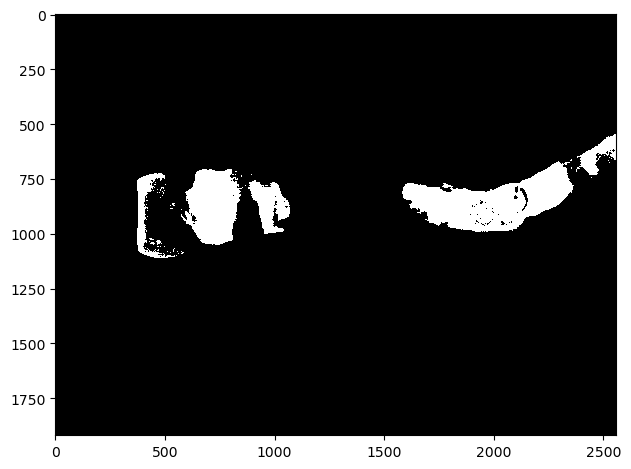

In [130]:
imshow(bone_mask)

In [131]:
bone_mask = morphology.remove_small_objects(bone_mask, min_size=64)

In [132]:
#labeled_bone_mask = measure.label(bone_mask)

In [133]:
#imshow(labeled_bone_mask, cmap="gray")

In [134]:
#bone_mask

In [135]:
rowsum = bone_mask.sum(axis=1);
idx_row = np.where(rowsum > 0)
colsum = bone_mask.sum(axis=0);
idx_col = np.where(colsum > 0)

In [136]:
bone_mask_cropped = bone_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]
cart_mask_cropped = cart_mask[np.min(idx_row):np.max(idx_row), np.min(idx_col):np.max(idx_col)]

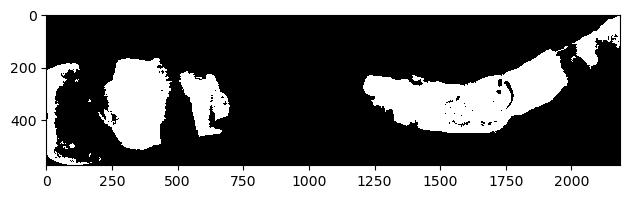

In [137]:
imshow(bone_mask_cropped, cmap="gray")

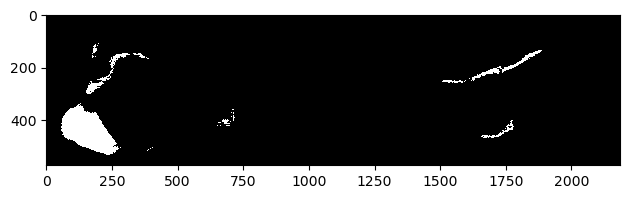

In [138]:
imshow(cart_mask_cropped, cmap="gray")

In [139]:
colsum = bone_mask_cropped.sum(axis=0);
idx_col = np.where(colsum == 0)
colsum2 = cart_mask_cropped.sum(axis = 0)

In [67]:
def find_max_gap(idx_col):
    import numpy as np
    
    index_gap = 1
    gap_size2save = 0
    gap_idx_2save = []
    gap_size = 0
    gap_idx = []
    
    
    for idx in idx_col:
        #print(idx)
        if gap_size == 0: ## gap starting point
            gap_idx.append(idx)
            gap_size = gap_size + 1
            idx_prev = idx
        else:
            diff = idx - idx_prev
            
            if diff > 1: ## gap ending point
                #print(idx)
                if gap_size2save == 0:
                    gap_size2save = gap_size
                    gap_idx_2save = gap_idx
                else:
                    if gap_size >= gap_size2save:
                        gap_size2save = gap_size
                        gap_idx_2save = gap_idx
                
                gap_size = 0
                gap_idx = []
                index_gap = index_gap + 1
                
            else:
                gap_size = gap_size + 1 ## increase the gap
                gap_idx.append(idx)
                idx_prev = idx
    if index_gap == 1: # in case there is one gap
        gap_size2save = gap_size
        gap_idx_2save = gap_idx
    
    return(gap_idx_2save)

In [68]:
gap_idx = find_max_gap(idx_col[0])

In [69]:
np.min(gap_idx)

np.int64(701)

In [126]:
bone_len = 200
if np.min(gap_idx) < bone_len:
    bone_len = np.min(gap_idx)
bone_mask_gap = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.max(gap_idx) + bone_len)]
cart_mask_gap = cart_mask_cropped[:, (np.min(gap_idx)):(np.max(gap_idx))]

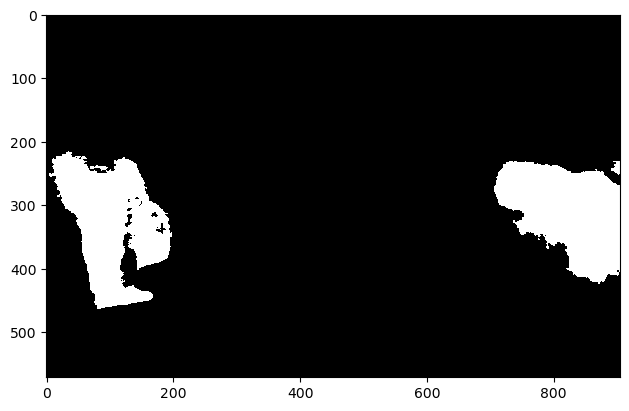

In [127]:
imshow(bone_mask_gap, cmap="gray")

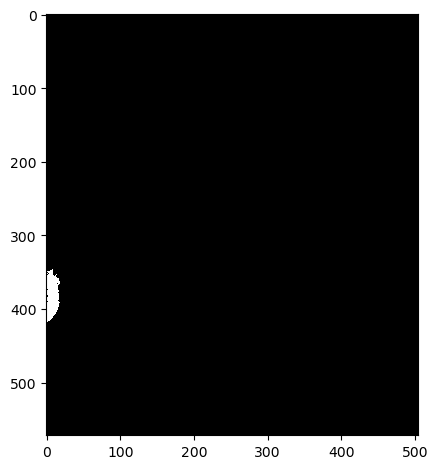

In [128]:
imshow(cart_mask_gap, cmap="gray")

In [77]:
colsum_cart = cart_mask_gap.sum(axis=0);
idx_col_cart = np.where(colsum_cart == 0)
gap_idx_cart = find_max_gap(idx_col_cart[0])

In [78]:
#idx_col_cart

In [121]:
from scipy.signal import argrelextrema
pct_cutPlan = 1/3

In [122]:
bone_left = bone_mask_cropped[:, (np.min(gap_idx)-bone_len):(np.min(gap_idx))]
colsum_left = bone_left.sum(axis=0)
colsum_left = colsum_left[::-1]
#print(colsum_left[0:99])
diff = abs(colsum_left - np.max(colsum_left) * pct_cutPlan)
#print(diff)
#print(diff.argmin(axis=0))
dist_left = argrelextrema(diff, np.less)[0][0]
print(dist_left)

[ 76.66666667  73.66666667  69.66666667  66.66666667  48.66666667
  38.66666667  24.66666667  16.66666667  10.66666667   9.66666667
   6.66666667   5.66666667   4.66666667   4.66666667   2.66666667
  13.66666667  12.66666667   9.66666667   5.66666667   2.33333333
   5.33333333   5.33333333   8.33333333  11.33333333   5.33333333
   7.33333333   8.33333333  10.33333333  11.33333333  12.33333333
  13.33333333  13.33333333  21.33333333  28.33333333  35.33333333
  36.33333333  37.33333333  43.33333333  46.33333333  49.33333333
  52.33333333  54.33333333  54.33333333  59.33333333  69.33333333
  72.33333333  76.33333333  80.33333333  77.33333333  78.33333333
  82.33333333  89.33333333  91.33333333  98.33333333  99.33333333
 102.33333333  92.33333333  91.33333333  87.33333333  84.33333333
  84.33333333  85.33333333  90.33333333  91.33333333  83.33333333
  75.33333333  68.33333333  58.33333333  52.33333333  46.33333333
  52.33333333  53.33333333  58.33333333  62.33333333  64.33333333
  73.33333

In [123]:
bone_right = bone_mask_cropped[:, (np.max(gap_idx)):(np.max(gap_idx) + bone_len)]
colsum_right = bone_right.sum(axis=0)
#colsum_right = colsum_right[::-1]
#print(colsum_right)
diff_right = abs(colsum_right - np.max(colsum_right) * pct_cutPlan)
#print(diff.argmin(axis=0))
dist_right = argrelextrema(diff_right, np.less)[0][0]

print(dist_right)

14


In [124]:
length_gapCart = len(gap_idx_cart)
length_bone = len(gap_idx)
print(length_gapCart, length_bone, dist_left, dist_right)

486 506 14 14


In [125]:
pct_closed = 1 - length_gapCart/(length_bone + dist_left + dist_right)
print(pct_closed)
pct_closed = 1 - length_gapCart/(length_bone )
print(pct_closed)

0.0898876404494382
0.03952569169960474


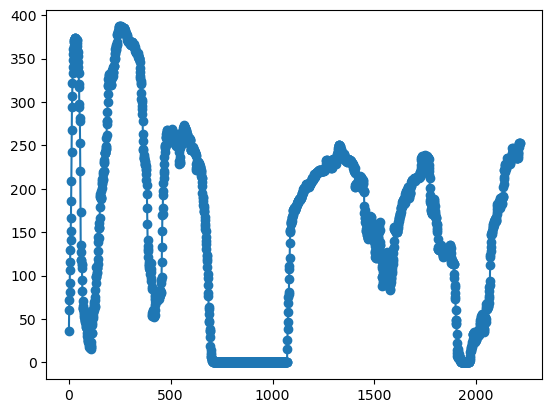

In [96]:
indices = np.arange(len(colsum))
plt.plot(indices, colsum, marker = 'o')

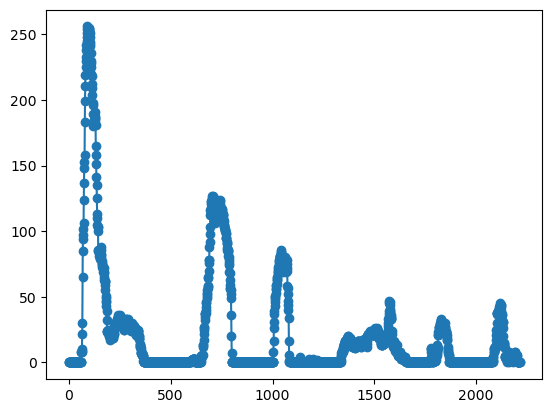

In [97]:
indices2 = np.arange(len(colsum2))
plt.plot(indices2, colsum2, marker = 'o')

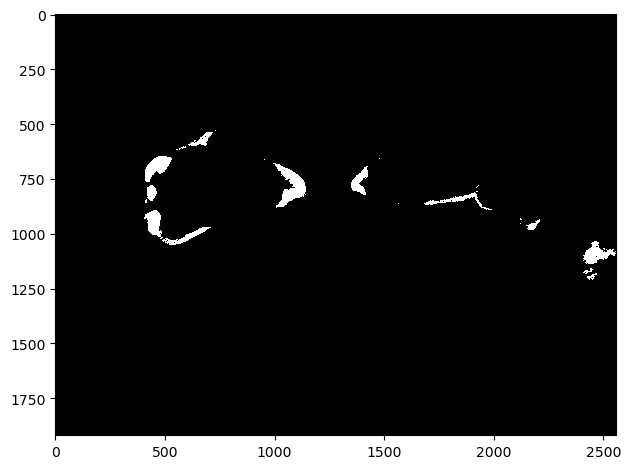

In [38]:
imshow(cart_mask)

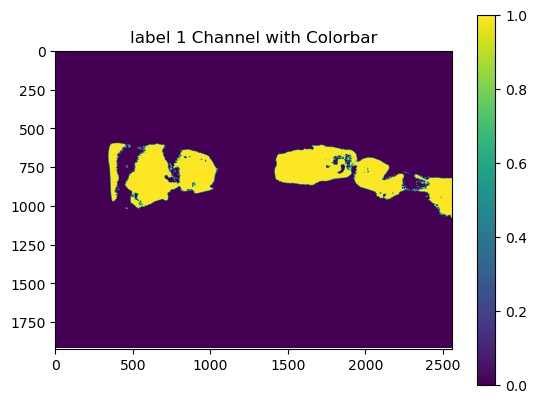

In [28]:
# Plot Hue Channel with Colorbar
plt.imshow(img_prob[:, :, 0] > 0.7)
plt.title('label 1 Channel with Colorbar')
plt.colorbar()
plt.show()

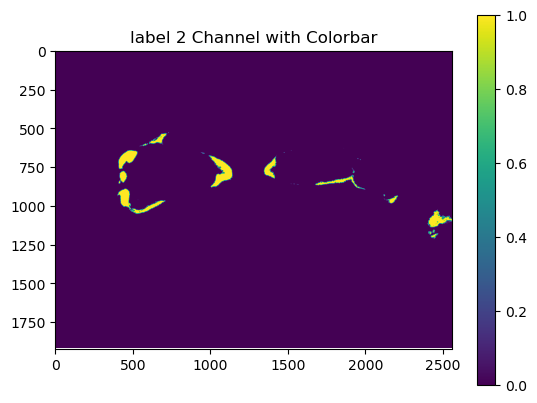

In [24]:
# Plot Hue Channel with Colorbar
plt.imshow(img_prob[:, :, 1] > 0.8)
plt.title('label 2 Channel with Colorbar')
plt.colorbar()
plt.show()

In [14]:
inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/axolotl_limb_CSD/AA_LNP-aug2025/"
#fileName = '675995-LNP1-limb2.jpg'
fileName = "675930-LNP3-limb2.czi"
fileName = "675911-LNP3-limb2.czi"
#fileName = '675907-LNP4-limb1.jpg'

In [15]:
## read czi file (original code https://biapol.github.io/Image-data-science-with-Python-and-Napari-EPFL2022/day2b_Working_with_Images/04_Image_file_formats.html)
#img = czifile.imread(os.path.join(inputDir, fileName))
#img.shape
#czi_dimstring = img.axes
# shape will give you the dimensions of the array
#czi_shapeinfo = img.shape

In [16]:
## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
img = AICSImage(os.path.join(inputDir, fileName))

In [17]:
image = img.data #returns 6D STCZYX numpy array

In [18]:
print(image.shape)
print(img.dims)  # returns string "STCZYX"
print(img.shape)  # returns tuple of dimension sizes in STCZYX order

(1, 1, 1, 1920, 2560, 3)
<Dimensions [T: 1, C: 1, Z: 1, Y: 1920, X: 2560, S: 3]>
(1, 1, 1, 1920, 2560, 3)


In [19]:
# Metadata Reading (https://allencellmodeling.github.io/aicsimageio/index.html)
img.channel_names  # returns a list of string channel names found in the metadata

[np.str_('C1')]

In [20]:
print(img.physical_pixel_sizes.Z)  # returns the Z dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata

None
0.275
0.275


In [20]:
s1 = img.get_image_data("ZYX", C=0, S=0, T=0)
s2 = img.get_image_data("ZYX", C=0, S=1, T=0)
s3 = img.get_image_data("ZYX", C=0, S=2, T=0)

In [16]:
print(s1.shape) 
print(s2.shape)

(1, 1920, 2560)
(1, 1920, 2560)


In [17]:
np.max(s1), np.max(s2)

(np.uint8(255), np.uint8(255))

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/pyclesperanto_prototype/_tier9/_imshow.py:35: UserWarning: cle.imshow is deprecated, use stackview.imshow instead.
  warnings.warn("cle.imshow is deprecated, use stackview.imshow instead.")


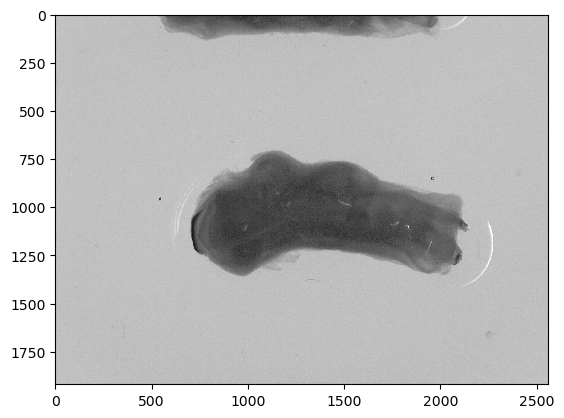

In [18]:
imshow(s1)

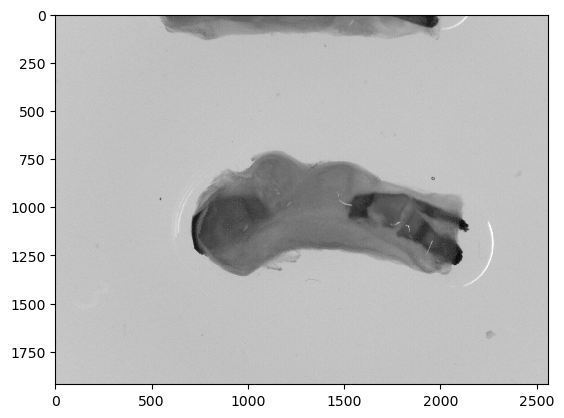

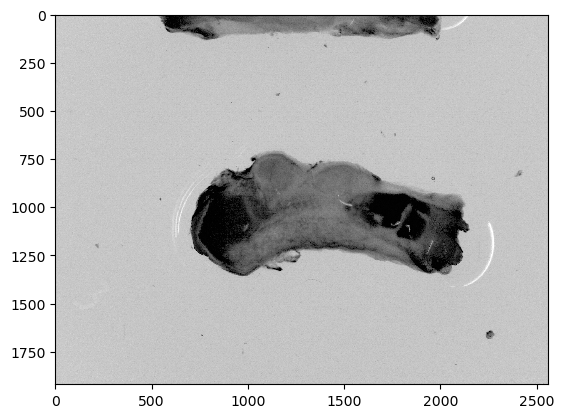

(None, None)

In [21]:
imshow(s2)

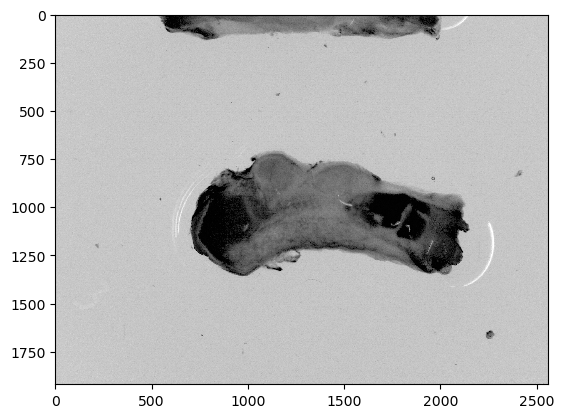

In [22]:
imshow(s3)